In [2]:
import numpy as np
import random
import importlib
import matplotlib.pyplot as plt
from itertools import cycle
from pathlib import Path
import Environment
import Agent
importlib.reload(Environment)
importlib.reload(Agent)
from Environment import LimitHoldemEnv
from Agent   import DQNAgent

In [2]:
NUM_EPISODES    = 100000
EVAL_EVERY      = 2000      # evaluate win-rate every N episodes
EVAL_EPISODES   = 2000
STATE_DIM       = 72
NUM_ACTIONS     = 4
LR              = 1e-4
GAMMA           = 0.99
EPSILON_START   = 1.0
EPSILON_END     = 0.02      # floor limit of exploration rate after ε decays
BATCH_SIZE      = 128
BUFFER_CAPACITY = 100000
TARGET_UPDATE   = 1000
MIN_BUFFER      = 1000
HIDDEN          = 256

# Declining exploration for ~80% of the training horizon (H = 100k episodes).
#   - If decay was 0.9999, ε would hit the floor limit too soon (~40% of the horizon).
#   - If decay was 0.99999, ε would not hit the floor limit fast enough (within the horizon limit)
#   - With decay = 0.99995, we ensure smooth enough decaying while leaving enough training time for maximum exploitation
EPSILON_DECAY   = 0.99995   # ε(t) = 0.99995^t


In [3]:
def training_game(env, agent):
    """
    Play one hand with learning.

    Args:
        env   : LimitHoldemEnv instance
        agent : DQNAgent instance

    Returns:
        reward : float  — chip payoff for the DQN agent
    """
    state, mask = env.reset()
    done = False

    while not done:
        action = agent.act(state, mask)
        next_state, reward, done, next_mask = env.step(action)

        agent.store(state, action, reward, next_state, done, next_mask)
        agent.learn()

        state = next_state
        mask  = next_mask

    return reward

In [4]:
def testing_game(env, agent):
    """
    Play one hand without learning (greedy policy).
    Args:
        env   : LimitHoldemEnv instance
        agent : DQNAgent instance
    Returns:
        reward : float  — chip payoff for the DQN agent
    """
    state, mask = env.reset()
    done = False
    tempEpsilon = agent.epsilon
    agent.epsilon = 0   # Disable exploration during testing

    while not done:
        action = agent.act(state, mask)
        next_state, reward, done, next_mask = env.step(action)
        state = next_state
        mask  = next_mask
        
    agent.epsilon= tempEpsilon  # Restore ε after the test is completed
    return reward

In [5]:
def train_agent(num_episodes, opponent_style, save_path):
    """Train DQN agent against a fixed-style opponent."""

    agent = DQNAgent(
        state_dim       = STATE_DIM,
        num_actions     = NUM_ACTIONS,
        lr              = LR,
        gamma           = GAMMA,
        epsilon_start   = EPSILON_START,
        epsilon_end     = EPSILON_END,
        epsilon_decay   = EPSILON_DECAY,          # decay handled here, not inside learn()
        batch_size      = BATCH_SIZE,
        buffer_capacity = BUFFER_CAPACITY,
        target_update   = TARGET_UPDATE,
        min_buffer      = MIN_BUFFER,
        hidden          = HIDDEN,
    )
    agent.epsilon = EPSILON_START      # set manually; decay done per episode below

    fixed_styles       = ['Random', 'Limping', 'Tight', 'Aggressive']
    game_rewards       = np.zeros(num_episodes)
    cumulative_rewards = np.zeros(num_episodes)
    if opponent_style != 'Mixed':
        env = LimitHoldemEnv(opponent_style=opponent_style)
        
    for game_idx in range(num_episodes):

        if opponent_style == 'Mixed':
            env = LimitHoldemEnv(rnd.choice(fixed_styles))
        reward = training_game(env, agent)
        
        game_rewards[game_idx]       = reward
        cumulative_rewards[game_idx] = cumulative_rewards[game_idx-1] + reward if game_idx > 0 else reward

        agent.epsilon = max(EPSILON_END, EPSILON_DECAY * agent.epsilon)

        #if (game_idx + 1) % EVAL_EVERY == 0:
        #    wins = sum(1 for _ in range(EVAL_EPISODES) if testing_game(env, agent) > 0)
        #    win_rate = wins / EVAL_EPISODES
        #    avg_reward = np.mean(game_rewards[max(0, game_idx - EVAL_EVERY + 1): game_idx + 1])
        #    print(
        #        f'Episode {game_idx+1:>6,}  |  '
        #        f'win-rate: {win_rate:.1%}  |  '
        #        f'avg reward: {avg_reward:+.3f}  |  '
        #        f'ε: {agent.epsilon:.4f}'
        #    )
    agent.save(save_path)
    np.savetxt(f'./data/training/dqn_vs_{opponent_style}.csv', cumulative_rewards)

    plt.figure()
    plt.title(f"Agent's Reward vs {opponent_style} Opponent")
    plt.xlabel('Game Number')
    plt.ylabel('Cumulative Score')
    plt.plot(np.arange(1, num_episodes + 1), cumulative_rewards, label='Cumulative Reward')
    plt.grid()
    plt.legend()
    plt.savefig(f'./data/images/dqn_vs_{opponent_style}.jpg')
    plt.show()

    return agent, game_rewards, cumulative_rewards

Training DQN agent against Random opponent...


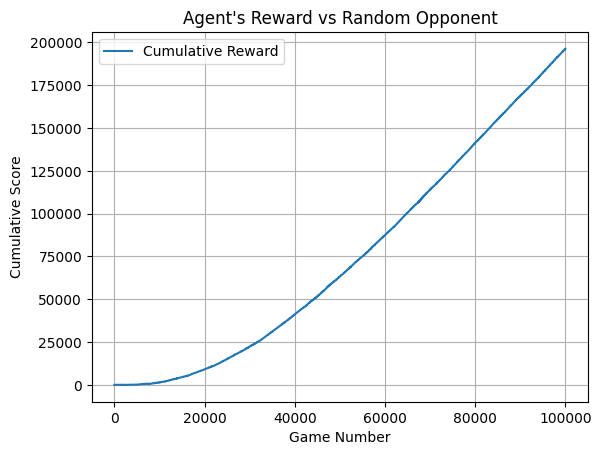


Training complete!
Training DQN agent against Limping opponent...


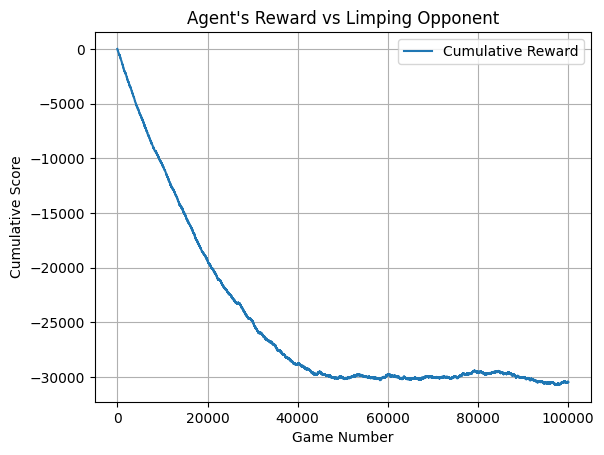


Training complete!
Training DQN agent against Tight opponent...


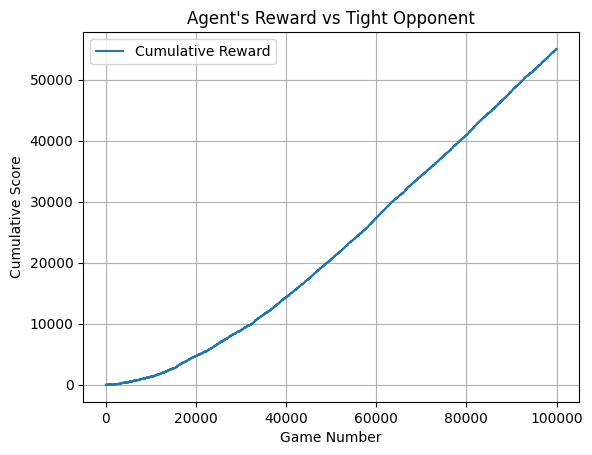


Training complete!
Training DQN agent against Aggressive opponent...


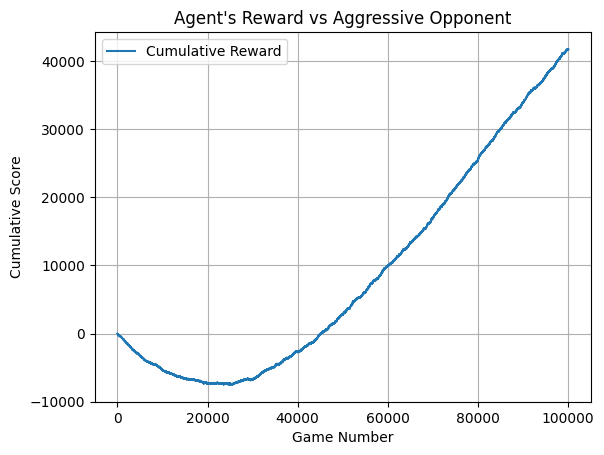


Training complete!


In [6]:
opp_styles = ['Random', 'Limping', 'Tight', 'Aggressive']
for style in opp_styles:
    print(f'Training DQN agent against {style} opponent...')
    train_agent(num_episodes  = NUM_EPISODES, opponent_style = style, save_path= f'./data/DQNs/dqn_vs_{style}.pt')
    print('\nTraining complete!')

In [6]:
def test_agent(num_episodes, opponent_style, load_path, trained_against_style):
    """Evaluate a saved DQN agent against a fixed-style opponent."""

    agent = DQNAgent(state_dim = STATE_DIM, num_actions = NUM_ACTIONS)
    agent.load(load_path)
    agent.epsilon = 0.0     # pure greedy during evaluation

    fixed_styles       = ['Random', 'Limping', 'Tight', 'Aggressive']
    round_rewards      = np.zeros(num_episodes)
    cumulative_rewards = np.zeros(num_episodes)
    if opponent_style != 'Mixed':
        env = LimitHoldemEnv(opponent_style=opponent_style)
        
    for game_idx in range(num_episodes):
        if opponent_style == 'Mixed':
            style = random.choice(fixed_styles)
            env   = LimitHoldemEnv(opponent_style=style)
        round_rewards[game_idx] = testing_game(env, agent)
        cumulative_rewards[game_idx] = cumulative_rewards[game_idx-1] + round_rewards[game_idx] if game_idx > 0 else round_rewards[game_idx]

    np.savetxt(f'./data/testing/{trained_against_style}_agent_vs_{opponent_style}.csv', round_rewards, delimiter=',')

    plt.figure()
    plt.title(f"{trained_against_style} Agent's Reward vs {opponent_style} Opponent")
    plt.xlabel('Game Number')
    plt.ylabel('Cumulative Score')
    plt.plot(np.arange(1, num_episodes + 1), cumulative_rewards, label='Cumulative Reward')
    plt.grid()
    plt.legend()
    plt.savefig(f'./data/images/{trained_against_style}_agent_vs_{opponent_style}.jpg')
    plt.show()


Evaluation of agent trained vs Random opponent. Opponent style: Random


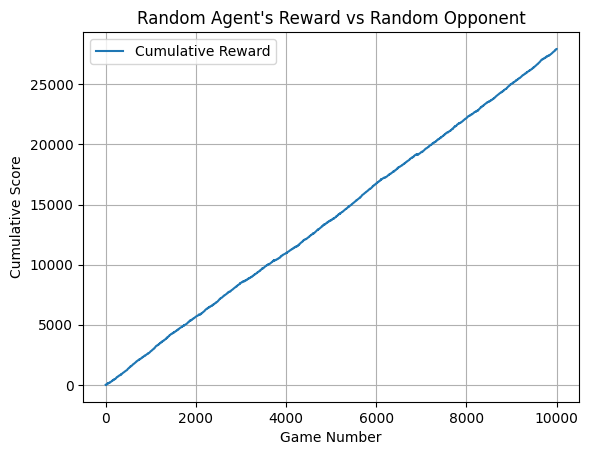


Test complete!

Evaluation of agent trained vs Tight opponent. Opponent style: Random


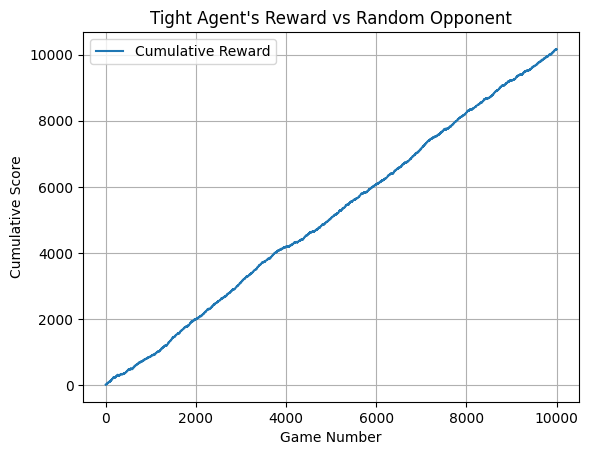


Test complete!

Evaluation of agent trained vs Limping opponent. Opponent style: Random


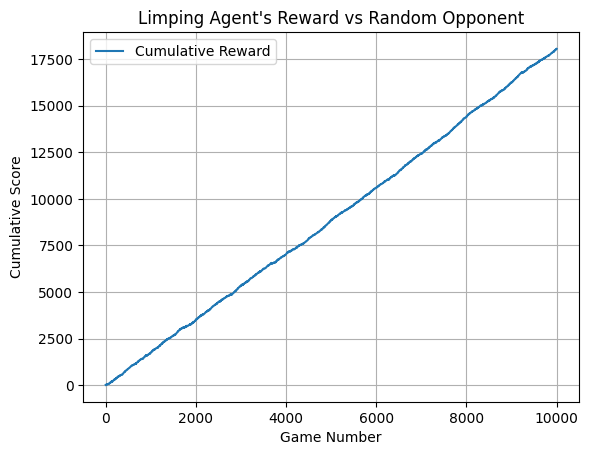


Test complete!

Evaluation of agent trained vs Aggressive opponent. Opponent style: Random


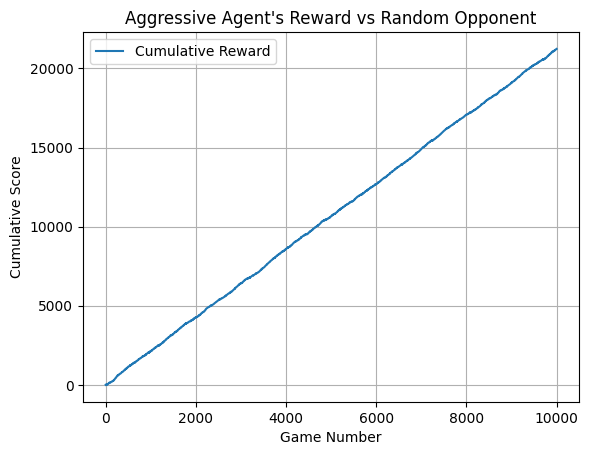


Test complete!

Evaluation of agent trained vs Random opponent. Opponent style: Tight


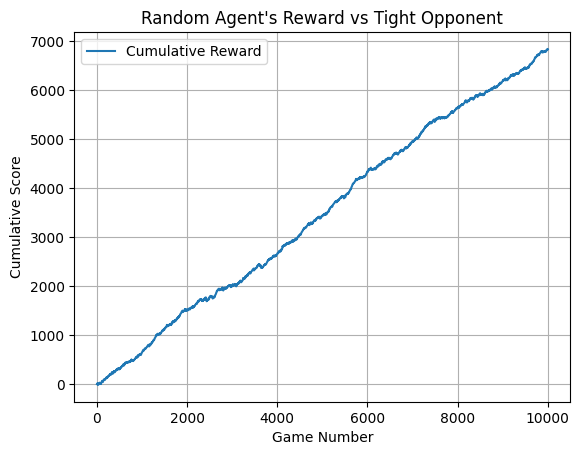


Test complete!

Evaluation of agent trained vs Tight opponent. Opponent style: Tight


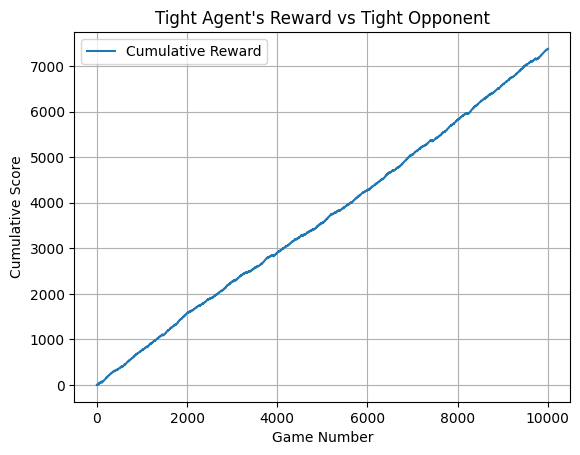


Test complete!

Evaluation of agent trained vs Limping opponent. Opponent style: Tight


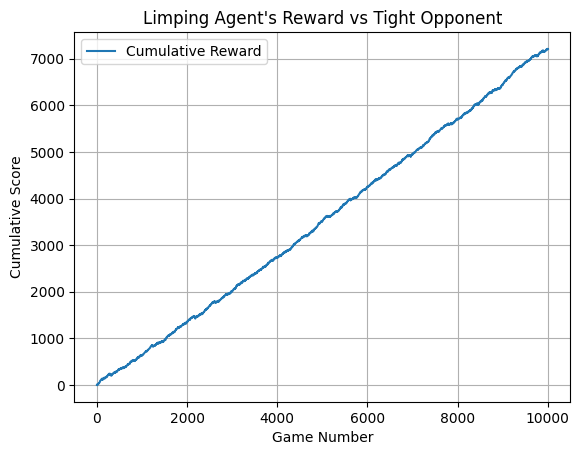


Test complete!

Evaluation of agent trained vs Aggressive opponent. Opponent style: Tight


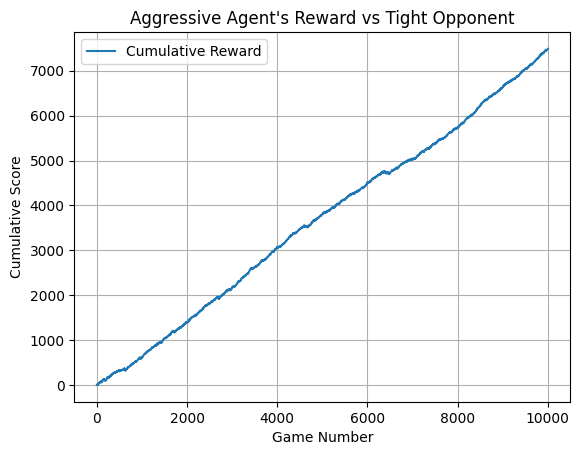


Test complete!

Evaluation of agent trained vs Random opponent. Opponent style: Limping


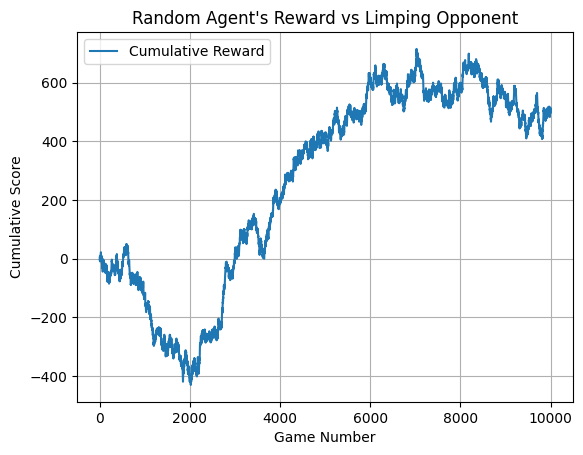


Test complete!

Evaluation of agent trained vs Tight opponent. Opponent style: Limping


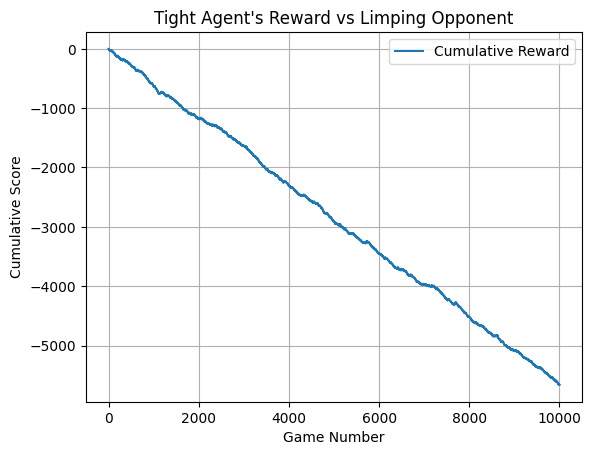


Test complete!

Evaluation of agent trained vs Limping opponent. Opponent style: Limping


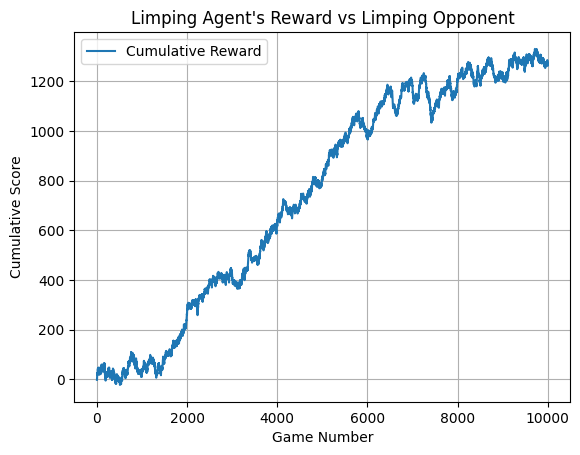


Test complete!

Evaluation of agent trained vs Aggressive opponent. Opponent style: Limping


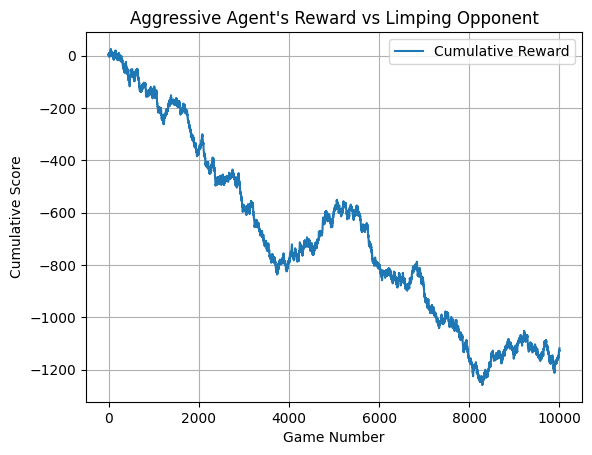


Test complete!

Evaluation of agent trained vs Random opponent. Opponent style: Aggressive


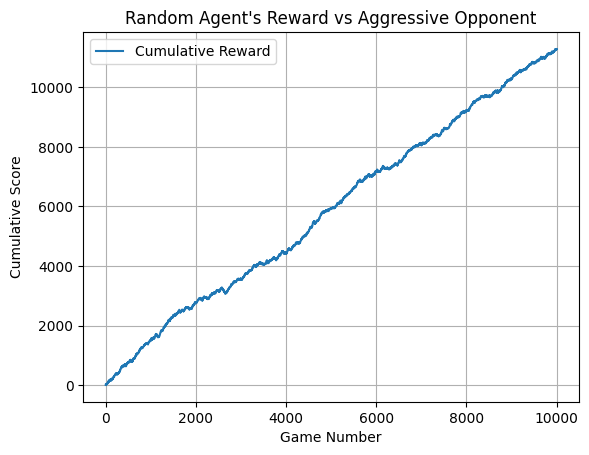


Test complete!

Evaluation of agent trained vs Tight opponent. Opponent style: Aggressive


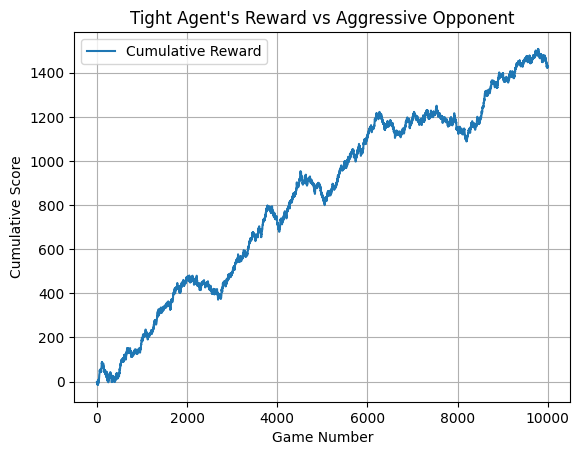


Test complete!

Evaluation of agent trained vs Limping opponent. Opponent style: Aggressive


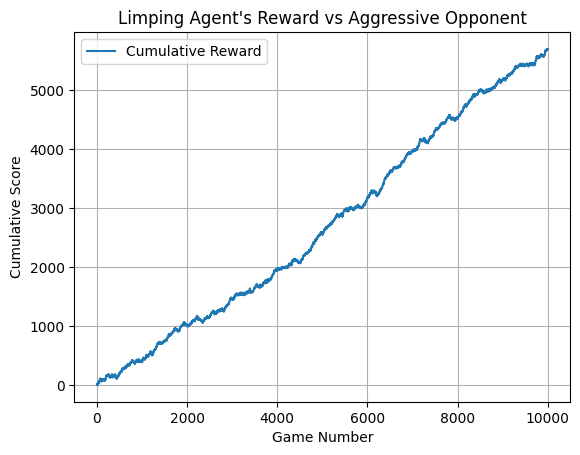


Test complete!

Evaluation of agent trained vs Aggressive opponent. Opponent style: Aggressive


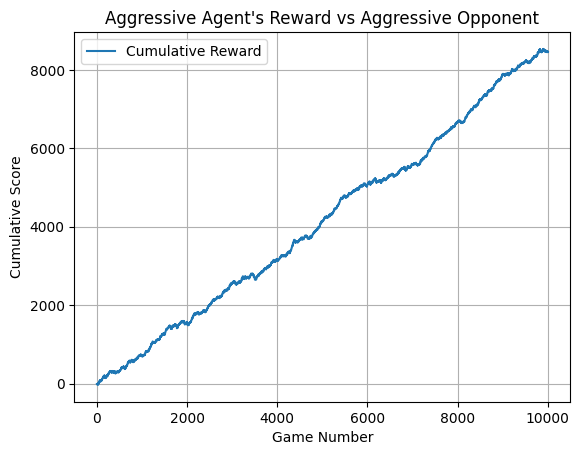


Test complete!

Evaluation of agent trained vs Random opponent. Opponent style: Mixed


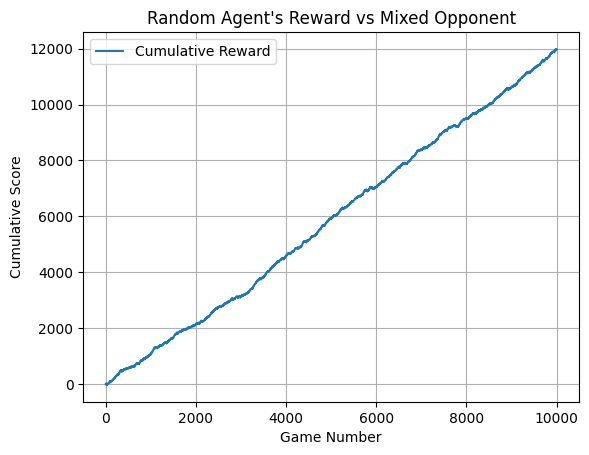


Test complete!

Evaluation of agent trained vs Tight opponent. Opponent style: Mixed


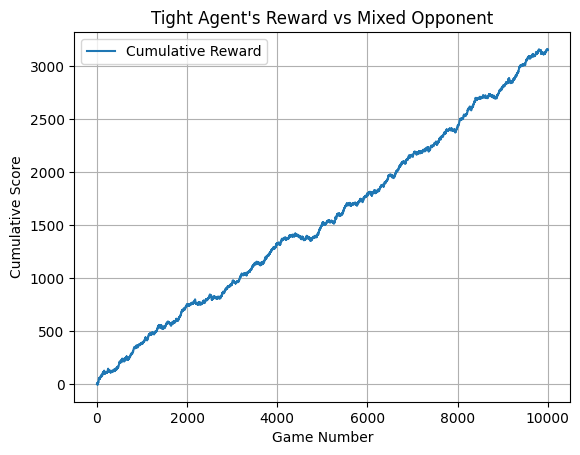


Test complete!

Evaluation of agent trained vs Limping opponent. Opponent style: Mixed


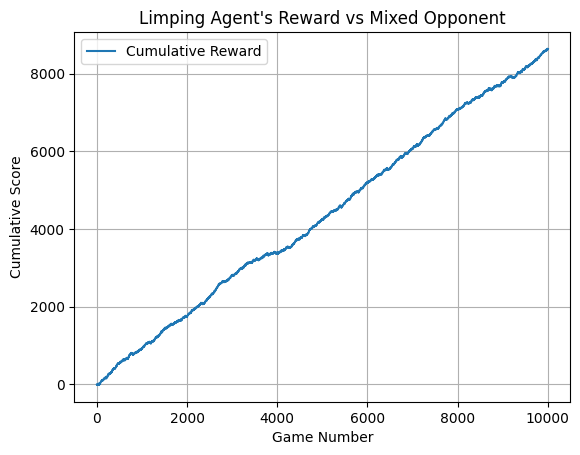


Test complete!

Evaluation of agent trained vs Aggressive opponent. Opponent style: Mixed


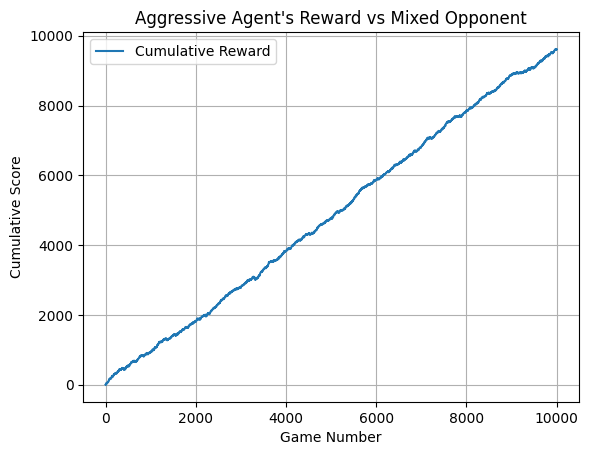


Test complete!
Final mean round rewards per agent and opponent:
[[ 2.79425  0.6832   0.0504   1.12755  1.1986 ]
 [ 1.01675  0.7375  -0.5659   0.143    0.3157 ]
 [ 1.80495  0.7204   0.1269   0.5696   0.8638 ]
 [ 2.1233   0.7485  -0.1118   0.8451   0.9609 ]]


In [8]:
opp_styles = ['Random', 'Tight', 'Limping', 'Aggressive', 'Mixed']
size = len(opp_styles)
mean_round_rewards = np.zeros((size-1, size))
for i in range(size):
    for j in range(size-1):
        print(f"\nEvaluation of agent trained vs {opp_styles[j]} opponent. Opponent style: {opp_styles[i]}")
        test_agent(num_episodes = 10000, opponent_style = opp_styles[i], load_path = f'./data/DQNs/dqn_vs_{opp_styles[j]}.pt', trained_against_style = opp_styles[j])
        mean_round_rewards[j,i] = np.mean(np.loadtxt(f"./data/testing/{opp_styles[j]}_agent_vs_{opp_styles[i]}.csv"))
        print("\nTest complete!")

print("Final mean round rewards per agent and opponent:")
print(mean_round_rewards, sep = "|")
np.savetxt(f"./data/Final_Results.csv", mean_round_rewards, "%.2f", delimiter = "\t|\t")

In [7]:
class DQNOpponent:
    """
    Wraps a trained DQNAgent so it can be plugged into LimitHoldemEnv
    as the opponent.  LimitHoldemEnv calls:
        opponent.reset()
        opponent.act(hole_cards, comm_cards, legal_strings)
    """

    # Maps RLCard integer actions to strings (needed by the environment)
    INT_TO_STR = {0: 'call', 1: 'raise', 2: 'fold', 3: 'check'}
    STR_TO_INT = {'call': 0, 'raise': 1, 'fold': 2, 'check': 3}

    def __init__(self, agent: DQNAgent, env_ref: LimitHoldemEnv):
        """
        Args:
            agent   : trained DQNAgent (epsilon should be 0.0)
            env_ref : the LimitHoldemEnv instance — used to read the
                    opponent's current obs from RLCard directly
        """
        self.agent   = agent
        self.env_ref = env_ref

    def reset(self):
        pass    # DQNAgent is stateless between hands — nothing to reset

    def act(self, hole_cards, comm_cards, legal_strings):
        """
        Called by LimitHoldemEnv._opponent_step().
        Reads the opponent's obs directly from the RLCard env,
        runs the DQN forward pass, and returns a legal action string.
        """
        # ── Get the opponent's current obs from RLCard ───────── #
        # RLCard stores the last obs for each player internally.  #
        # We access it via the underlying env's get_state().      #
        try:
            raw_obs = self.env_ref._env.get_state(player_id=1)
            state   = raw_obs['obs'].astype(np.float32)
        except Exception:
            # Fallback: zero state — agent picks randomly among legal
            state = np.zeros(STATE_DIM, dtype=np.float32)

        # ── Build legal mask from the string list ────────────── #
        mask = np.zeros(NUM_ACTIONS, dtype=bool)
        for s in legal_strings:
            idx = self.STR_TO_INT.get(s)
            if idx is not None:
                mask[idx] = True

        if not mask.any():
            mask[:] = True   # safety fallback

        # ── Greedy action from DQN ───────────────────────────── #
        self.agent.epsilon = 0.0   # ensure greedy
        action_int = self.agent.act(state, mask)
        return self.INT_TO_STR.get(action_int, 'call')

In [8]:
def make_frozen_snapshot(agent):
    """Return a greedy non-learning copy of the agent at its current state."""
    snap = DQNAgent(state_dim=STATE_DIM, num_actions=NUM_ACTIONS)
    snap.online_net.load_state_dict(agent.online_net.state_dict())
    snap.target_net.load_state_dict(agent.target_net.state_dict())
    snap.epsilon = 0.0
    return snap

def load_specialist(style):
    """
    Load a trained DQN specialist from checkpoint.
    Returns None if the checkpoint does not exist yet.

    Args:
        style : str — one of 'Random', 'Limping', 'Tight', 'Aggressive', 'Mixed'
    """
    path = f'./data/DQNs/dqn_vs_{style}.pt'
    if not Path(path).exists():
        return None
    specialist = DQNAgent(state_dim=STATE_DIM, num_actions=NUM_ACTIONS)
    specialist.load(path)
    specialist.epsilon = 0.0
    return specialist


def make_specialist_opponent(style, env):
    """
    Try to build a DQNOpponent from a trained specialist checkpoint.
    Falls back to the baseline opponent if the checkpoint does not exist.

    Args:
        style : str             — opponent style label
        env   : LimitHoldemEnv  — environment instance to attach the opponent to
    """
    specialist = load_specialist(style)
    if specialist is not None:
        env._opponent = DQNOpponent(specialist, env)
    # If checkpoint missing, env keeps its default baseline opponent

In [9]:
def train_curriculum_agent(num_episodes, save_path):
    """
    Train a DQN agent against a random mix of the trained specialists.

    Each episode, one of the four specialist DQNs (trained via train_agent
    against Random / Limping / Tight / Aggressive) is chosen at random and
    used as the opponent. If a specialist checkpoint is missing, that style
    falls back to its baseline opponent automatically.

    Note: specialist checkpoints (dqn_vs_Random.pt etc.) must be trained
    first via train_agent() before running this.
    """

    agent = DQNAgent(
        state_dim       = STATE_DIM,
        num_actions     = NUM_ACTIONS,
        lr              = LR,
        gamma           = GAMMA,
        epsilon_start   = EPSILON_START,
        epsilon_end     = EPSILON_END,
        epsilon_decay   = 1.0,
        batch_size      = BATCH_SIZE,
        buffer_capacity = BUFFER_CAPACITY,
        target_update   = TARGET_UPDATE,
        min_buffer      = MIN_BUFFER,
        hidden          = HIDDEN
    )
    agent.epsilon = EPSILON_START

    specialist_styles  = ['Random', 'Limping', 'Tight', 'Aggressive']
    game_rewards       = np.zeros(num_episodes)
    cumulative_rewards = np.zeros(num_episodes)

    envs = {style: LimitHoldemEnv(style) for style in specialist_styles}
    specialists = {style: load_specialist(style) for style in specialist_styles}
    
    for game_idx in range(num_episodes):

        style = random.choice(specialist_styles)
        #env   = LimitHoldemEnv(opponent_style=style)
        #make_specialist_opponent(style, env)

        env = envs[style]
        make_specialist_opponent(env, specialists[style]) # no disk I/O
        
        reward = training_game(env, agent)

        game_rewards[game_idx] = reward
        cumulative_rewards[game_idx] = cumulative_rewards[game_idx-1] + reward if game_idx > 0 else reward

        agent.epsilon = max(EPSILON_END, EPSILON_DECAY * agent.epsilon)

        #if (game_idx + 1) % EVAL_EVERY == 0:
        #    style = random.choice(specialist_styles)
        #    env   = LimitHoldemEnv(opponent_style=style, seed=None)
        #    make_specialist_opponent(style, env)
        #    wins = sum(1 for _ in range(EVAL_EPISODES) if testing_game(env, agent) > 0)
        #    avg_reward = np.mean(game_rewards[max(0, game_idx - EVAL_EVERY + 1): game_idx + 1])
        #    print(
        #        f'Episode {game_idx+1:>6,}  |  '
        #        f'win-rate: {wins/EVAL_EPISODES:.1%}  |  '
        #        f'avg reward: {avg_reward:+.3f}  |  '
        #        f'ε: {agent.epsilon:.4f}'
        #    )

    agent.save(save_path)
    np.savetxt('./data/training/dqn_curriculum.csv', cumulative_rewards)

    plt.figure()
    plt.title("DQN Agent's Reward — Curriculum (mix of specialists)")
    plt.xlabel('Game Number')
    plt.ylabel('Cumulative Score')
    plt.plot(np.arange(1, num_episodes + 1), cumulative_rewards, label='Cumulative Reward')
    plt.grid()
    plt.legend()
    plt.savefig('./data/images/dqn_curriculum.jpg')
    plt.show()

    return agent, game_rewards, cumulative_rewards

Training DQN agent with curriculum...


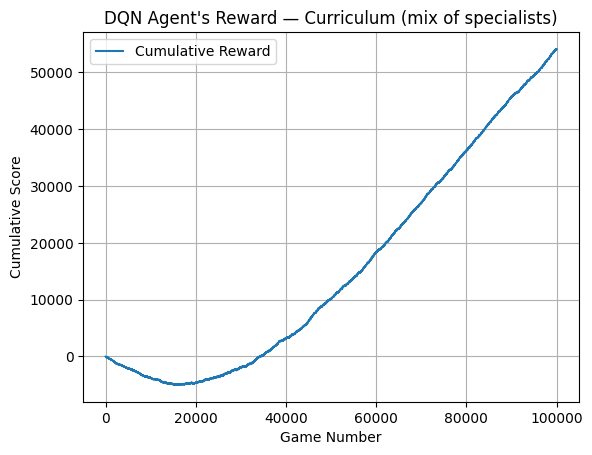


Curriculum training complete!


In [12]:
print('Training DQN agent with curriculum...')
train_curriculum_agent( num_episodes = NUM_EPISODES, save_path= './data/DQNs/dqn_vs_curriculum.pt')
print('\nCurriculum training complete!')

In [10]:
def train_vs_curriculum(num_episodes, curriculum_path, save_path):
    """
    Train a fresh DQN agent against the frozen curriculum agent.

    The curriculum agent (trained via train_curriculum_agent) is loaded,
    frozen (epsilon=0, no learning), and used as the opponent for every
    episode. Only the new agent learns.

    Args:
        num_episodes    : int  — episodes to train the new agent
        curriculum_path : str  — checkpoint of the curriculum agent to beat
        save_path       : str  — where to save the new agent
    """

    # ============================================================ #
    # Load the curriculum agent and freeze it as the opponent.     #
    # ============================================================ #
    curriculum_agent = DQNAgent(state_dim=STATE_DIM, num_actions=NUM_ACTIONS)
    curriculum_agent.load(curriculum_path)
    curriculum_agent.epsilon = 0.0

    # The new agent that will learn to beat the curriculum agent
    agent = DQNAgent(
        state_dim       = STATE_DIM,
        num_actions     = NUM_ACTIONS,
        lr              = LR,
        gamma           = GAMMA,
        epsilon_start   = EPSILON_START,
        epsilon_end     = EPSILON_END,
        epsilon_decay   = 1.0,
        batch_size      = BATCH_SIZE,
        buffer_capacity = BUFFER_CAPACITY,
        target_update   = TARGET_UPDATE,
        min_buffer      = MIN_BUFFER,
        hidden          = HIDDEN,
    )
    agent.epsilon = EPSILON_START

    game_rewards       = np.zeros(num_episodes)
    cumulative_rewards = np.zeros(num_episodes)

    for game_idx in range(num_episodes):

        # ============================================================ #
        # Opponent is always the frozen curriculum agent, wrapped in   #
        # DQNOpponent so the environment can call it.                  #
        # ============================================================ #
        env = LimitHoldemEnv(opponent_style='')
        env._opponent = DQNOpponent(curriculum_agent, env)

        reward = training_game(env, agent)

        game_rewards[game_idx]       = reward
        cumulative_rewards[game_idx] = cumulative_rewards[game_idx-1] + reward if game_idx > 0 else reward

        # ── Epsilon decays once per episode ───────────────────── #
        agent.epsilon = max(EPSILON_END, EPSILON_DECAY * agent.epsilon)

        #if (game_idx + 1) % EVAL_EVERY == 0:
        #    # Evaluate the new agent against the curriculum agent it is learning to beat
        #    env_eval = LimitHoldemEnv(opponent_style='Random', seed=SEED)
        #    env_eval._opponent = DQNOpponent(curriculum_agent, env_eval)
        #    wins = sum(1 for _ in range(EVAL_EPISODES) if testing_game(env_eval, agent) > 0)
        #    avg_reward = np.mean(game_rewards[max(0, game_idx - EVAL_EVERY + 1): game_idx + 1])
        #    print(
        #        f'Episode {game_idx+1:>6,}  |  '
        #        f'win-rate vs curriculum: {wins/EVAL_EPISODES:.1%}  |  '
        #        f'avg reward: {avg_reward:+.3f}  |  '
        #        f'ε: {agent.epsilon:.4f}'
        #    )

    agent.save(save_path)
    np.savetxt('./data/training/dqn_vs_curriculum.csv', cumulative_rewards)

    plt.figure()
    plt.title("New Agent's Reward — Training vs Curriculum Agent")
    plt.xlabel('Game Number')
    plt.ylabel('Cumulative Score')
    plt.plot(np.arange(1, num_episodes + 1), cumulative_rewards, label='Cumulative Reward')
    plt.grid()
    plt.legend()
    plt.savefig('./data/images/dqn_vs_curriculum.jpg')
    plt.show()

    return agent, game_rewards, cumulative_rewards

Preparing Master....


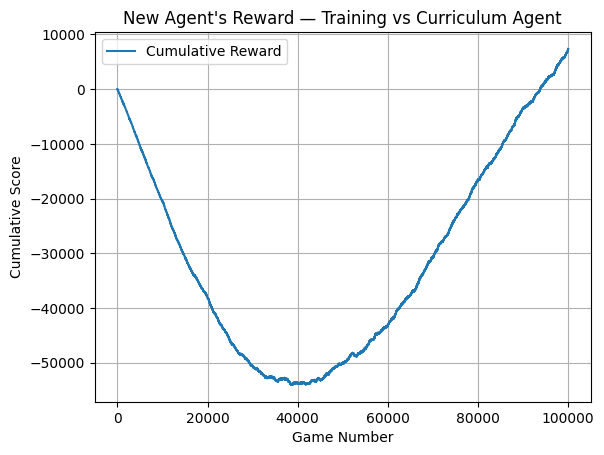

(<Agent.DQNAgent at 0x1704ab731a0>,
 array([-1. , -5. , -0.5, ..., 10. ,  9. ,  6. ]),
 array([-1.0000e+00, -6.0000e+00, -6.5000e+00, ...,  7.3435e+03,
         7.3525e+03,  7.3585e+03]))

In [14]:
print("Preparing Master....")
train_vs_curriculum( num_episodes    = NUM_EPISODES, curriculum_path = './data/DQNs/dqn_vs_curriculum.pt', save_path       = './data/DQNs/Horny_DQN.pt')

In [11]:
# ================================================================== #
# Final boss evaluation — the agent trained vs the curriculum agent   #
# is tested against every baseline, every specialist, AND the         #
# curriculum agent it was trained to beat.                            #
# ================================================================== #

def test_final_boss(num_episodes, load_path):
    """
    Evaluate the 'final boss' agent (trained via train_vs_curriculum)
    against every opponent: fixed-style baselines, individually trained
    DQN specialists, and the curriculum agent itself.

    Args:
        num_episodes : int  — hands to play per matchup
        load_path    : str  — path to the final boss checkpoint (.pt)

    Returns:
        mean_rewards : dict — { opponent_label : mean_reward }
    """

    # ============================================================ #
    # Load the final boss once; reuse for all matchups.            #
    # epsilon=0 => pure greedy during evaluation.                  #
    # ============================================================ #
    boss = DQNAgent(state_dim=STATE_DIM, num_actions=NUM_ACTIONS)
    boss.load(load_path)
    boss.epsilon = 0.0

    fixed_styles = ['Random', 'Limping', 'Tight', 'Aggressive']
    mean_rewards = {}

    # ── Round 1: vs every fixed-style baseline ────────────────── #
    print('── Final Boss vs Fixed-Style Baselines ──')
    for style in fixed_styles:
        env           = LimitHoldemEnv(opponent_style=style)
        round_rewards = np.zeros(num_episodes)
        cumulative    = np.zeros(num_episodes)

        for game_idx in range(num_episodes):
            round_rewards[game_idx] = testing_game(env, boss)
            cumulative[game_idx]    = cumulative[game_idx-1] + round_rewards[game_idx] if game_idx > 0 else round_rewards[game_idx]

        mean_r = np.mean(round_rewards)
        win_r  = np.mean(round_rewards > 0)
        mean_rewards[style] = mean_r

        np.savetxt(f'./data/testing/boss_vs_{style}.csv', round_rewards, delimiter=',')

        plt.figure()
        plt.title(f"Final Boss's Reward vs {style} Opponent")
        plt.xlabel('Game Number')
        plt.ylabel('Cumulative Score')
        plt.plot(np.arange(1, num_episodes + 1), cumulative, label='Cumulative Reward')
        plt.grid()
        plt.legend()
        plt.savefig(f'./data/images/boss_vs_{style}.jpg')
        plt.show()

        print(f'  vs {style:<12}  win-rate: {win_r:.1%}  mean reward: {mean_r:+.3f}')

    # ── Round 2: vs each individually trained DQN specialist ─────#
    print('\n── Final Boss vs Individually Trained DQN Specialists ──')
    for style in fixed_styles:
        ckpt_path = f'./data/DQNs/dqn_vs_{style}.pt'
        if not Path(ckpt_path).exists():
            print(f'  [SKIP] No checkpoint found: dqn_vs_{style}.pt')
            continue

        # ======================================================== #
        # Load the specialist and wrap it in DQNOpponent so the    #
        # environment can call .reset() and .act() on it.          #
        # ======================================================== #
        specialist = DQNAgent(state_dim=STATE_DIM, num_actions=NUM_ACTIONS)
        specialist.load(ckpt_path)
        specialist.epsilon = 0.0

        env          = LimitHoldemEnv(opponent_style='Random')
        env.opponent = DQNOpponent(specialist, env)

        round_rewards = np.zeros(num_episodes)
        cumulative    = np.zeros(num_episodes)

        for game_idx in range(num_episodes):
            round_rewards[game_idx] = testing_game(env, boss)
            cumulative[game_idx]    = cumulative[game_idx-1] + round_rewards[game_idx] if game_idx > 0 else round_rewards[game_idx]

        label  = f'DQN-{style}'
        mean_r = np.mean(round_rewards)
        win_r  = np.mean(round_rewards > 0)
        mean_rewards[label] = mean_r

        np.savetxt(f'./data/testing/boss_vs_{label}.csv', round_rewards, delimiter=',')

        plt.figure()
        plt.title(f"Final Boss's Reward vs {label}")
        plt.xlabel('Game Number')
        plt.ylabel('Cumulative Score')
        plt.plot(np.arange(1, num_episodes + 1), cumulative, label='Cumulative Reward')
        plt.grid()
        plt.legend()
        plt.savefig(f'./data/images/boss_vs_{label}.jpg')
        plt.show()

        print(f'  vs {label:<16}  win-rate: {win_r:.1%}  mean reward: {mean_r:+.3f}')

    # ── Round 3: vs the curriculum agent it was trained to beat ──#
    print('\n── Final Boss vs Curriculum Agent ──')
    curriculum_path = './data/DQNs/dqn_vs_curriculum.pt'
    if Path(curriculum_path).exists():
        curriculum_agent = DQNAgent(state_dim=STATE_DIM, num_actions=NUM_ACTIONS)
        curriculum_agent.load(curriculum_path)
        curriculum_agent.epsilon = 0.0

        env          = LimitHoldemEnv(opponent_style='Random')
        env.opponent = DQNOpponent(curriculum_agent, env)

        round_rewards = np.zeros(num_episodes)
        cumulative    = np.zeros(num_episodes)

        for game_idx in range(num_episodes):
            round_rewards[game_idx] = testing_game(env, boss)
            cumulative[game_idx]    = cumulative[game_idx-1] + round_rewards[game_idx] if game_idx > 0 else round_rewards[game_idx]

        label  = 'Curriculum'
        mean_r = np.mean(round_rewards)
        win_r  = np.mean(round_rewards > 0)
        mean_rewards[label] = mean_r

        np.savetxt(f'./data/testing/boss_vs_{label}.csv', round_rewards, delimiter=',')

        plt.figure()
        plt.title("Final Boss's Reward vs Curriculum Agent")
        plt.xlabel('Game Number')
        plt.ylabel('Cumulative Score')
        plt.plot(np.arange(1, num_episodes + 1), cumulative, label='Cumulative Reward')
        plt.grid()
        plt.legend()
        plt.savefig('./data/images/boss_vs_Curriculum.jpg')
        plt.show()

        print(f'  vs {label:<12}  win-rate: {win_r:.1%}  mean reward: {mean_r:+.3f}')
    else:
        print(f'  [SKIP] No curriculum checkpoint found: {curriculum_path}')

    # ── Summary bar chart ─────────────────────────────────────── #
    labels = list(mean_rewards.keys())
    values = list(mean_rewards.values())
    colors = ['steelblue' if v > 0 else 'tomato' for v in values]

    plt.figure(figsize=(11, 5))
    plt.bar(labels, values, color=colors)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    plt.title('Final Boss — Mean Reward vs All Opponents')
    plt.xlabel('Opponent')
    plt.ylabel('Mean Reward per Hand')
    plt.xticks(rotation=30, ha='right')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.savefig('./data/images/boss_summary.jpg')
    plt.show()

    np.savetxt(
        './data/Boss_Results.csv',
        np.array(values).reshape(1, -1),
        fmt='%.3f',
        delimiter='\t|\t',
        header='\t|\t'.join(labels),
        comments=''
    )

    return mean_rewards

── Final Boss vs Fixed-Style Baselines ──


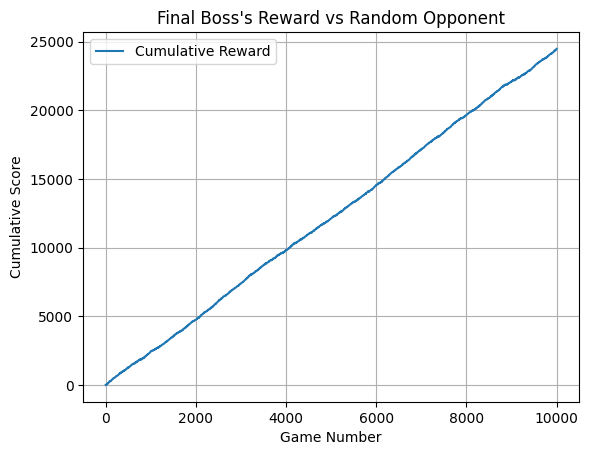

  vs Random        win-rate: 90.3%  mean reward: +2.448


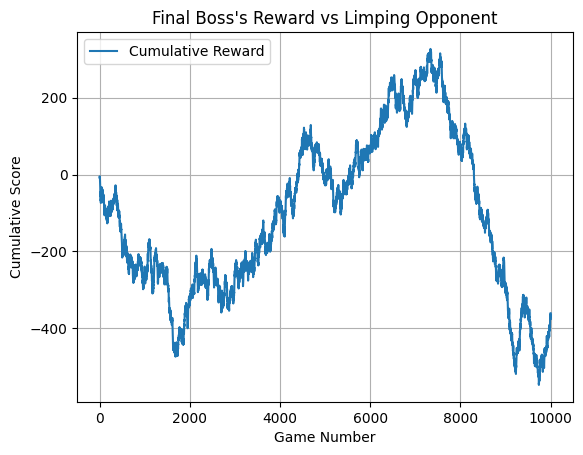

  vs Limping       win-rate: 46.9%  mean reward: -0.036


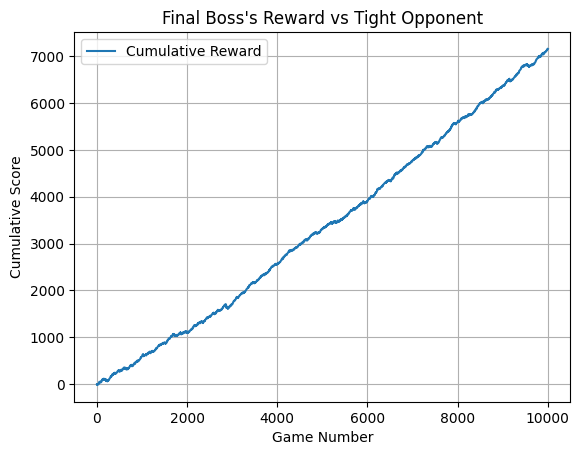

  vs Tight         win-rate: 89.9%  mean reward: +0.715


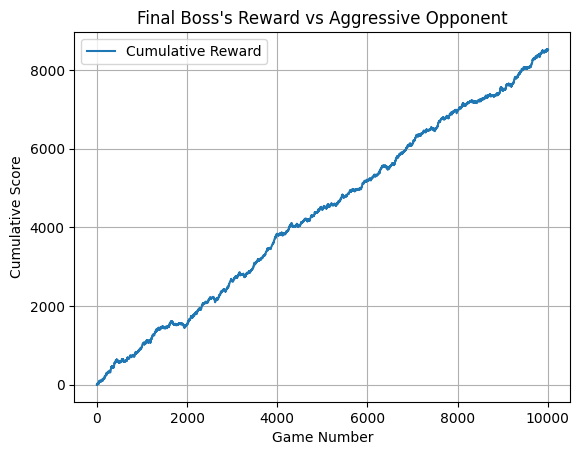

  vs Aggressive    win-rate: 77.7%  mean reward: +0.852

── Final Boss vs Individually Trained DQN Specialists ──


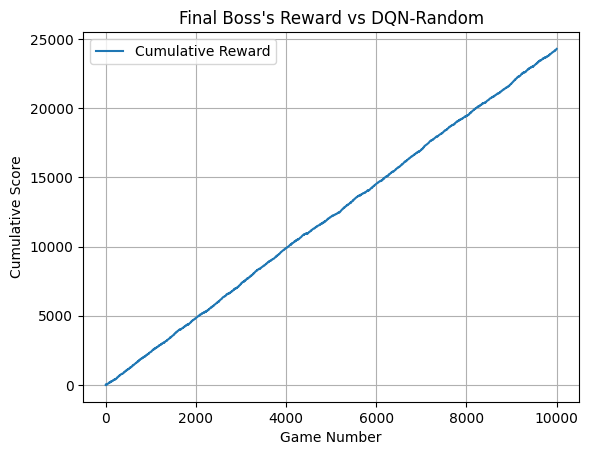

  vs DQN-Random        win-rate: 90.3%  mean reward: +2.428


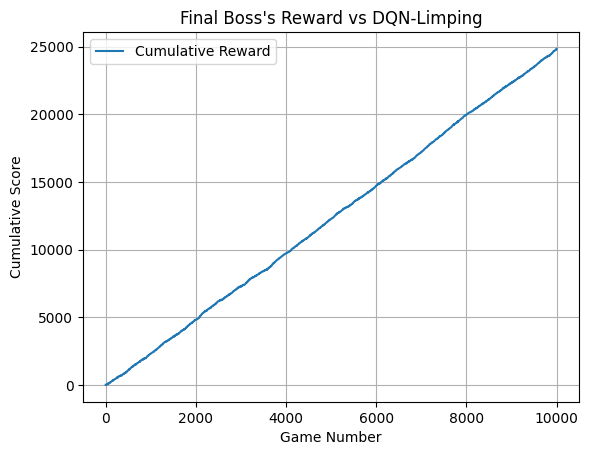

  vs DQN-Limping       win-rate: 90.6%  mean reward: +2.483


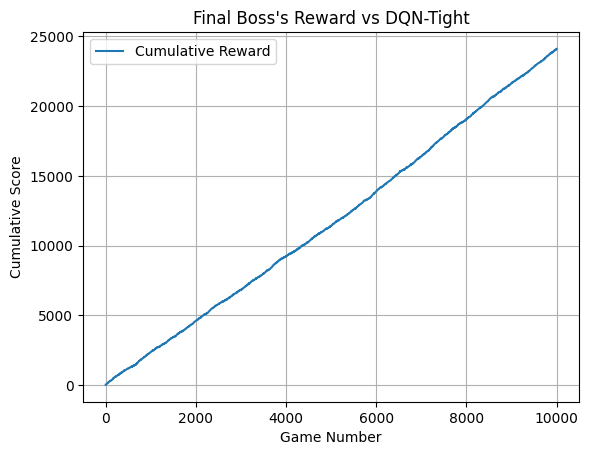

  vs DQN-Tight         win-rate: 90.3%  mean reward: +2.411


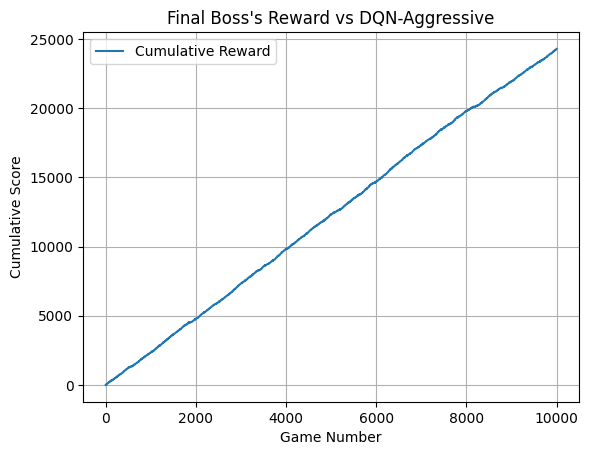

  vs DQN-Aggressive    win-rate: 90.2%  mean reward: +2.428

── Final Boss vs Curriculum Agent ──


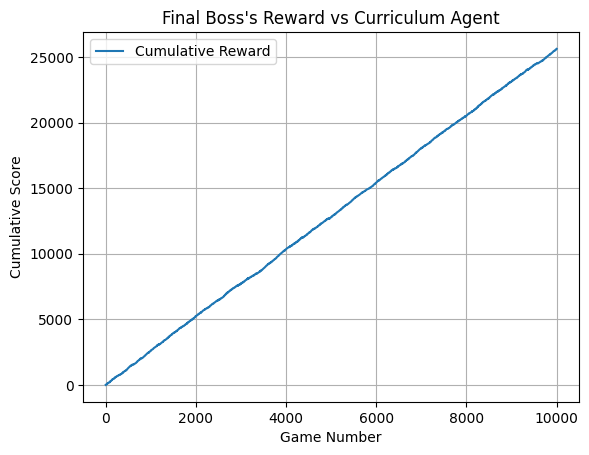

  vs Curriculum    win-rate: 90.7%  mean reward: +2.562


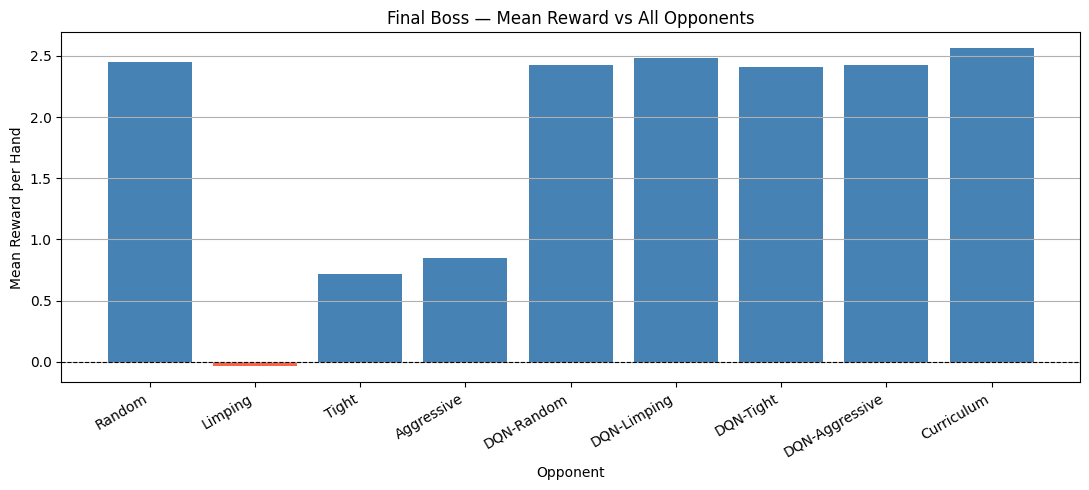


Final mean rewards:
  Random                +2.4478
  Limping               -0.0361
  Tight                 +0.7153
  Aggressive            +0.8516
  DQN-Random            +2.4285
  DQN-Limping           +2.4827
  DQN-Tight             +2.4108
  DQN-Aggressive        +2.4282
  Curriculum            +2.5621


In [13]:
mean_rewards = test_final_boss( num_episodes = 10_000, load_path = './data/DQNs/Horny_DQN.pt')
print('\nFinal mean rewards:')
for opp, r in mean_rewards.items():
    print(f'  {opp:<20}  {r:+.4f}')

In [12]:
# ============================================================
# PORTABLE AGENT EXPORT — single cell, no external files
#
# Αλλαξε μόνο αυτά:
# ============================================================
CHECKPOINT_PATH = './data/DQNs/dqn_vs_curriculum.pt'   # path to your saved .pt checkpoint
GROUP_NUMBER    = 17                 # your group number
AGENT_NAME      = "Horny_Bot"      # any descriptive name
# ============================================================

import copy, hashlib, json, re, tempfile, zipfile, textwrap
from pathlib import Path
import numpy as np
from Agent import DQNAgent

# ── 1. Φόρτωσε checkpoint ────────────────────────────────────
trained_agent = DQNAgent(state_dim=72, num_actions=4)
trained_agent.load(CHECKPOINT_PATH)
trained_agent.epsilon = 0.0
trained_agent.online_net.eval()
print(f"Loaded: steps={trained_agent.steps}")

# ── 2. Εξαγωγή weights σε .npz ───────────────────────────────
layers  = [l for l in trained_agent.online_net.net.children()
           if hasattr(l, "weight")]
np.savez("agent_weights.npz",
    W1=layers[0].weight.detach().cpu().numpy(),
    b1=layers[0].bias.detach().cpu().numpy(),
    W2=layers[1].weight.detach().cpu().numpy(),
    b2=layers[1].bias.detach().cpu().numpy(),
    W3=layers[2].weight.detach().cpu().numpy(),
    b3=layers[2].bias.detach().cpu().numpy(),
)
print("Weights saved → agent_weights.npz")

# ── 3. PortableDQNAgent (pure numpy, no PyTorch) ─────────────
class PortableDQNAgent:
    use_raw = False

    def __init__(self, npz_path):
        d = np.load(npz_path)
        self.W1, self.b1 = d["W1"], d["b1"]
        self.W2, self.b2 = d["W2"], d["b2"]
        self.W3, self.b3 = d["W3"], d["b3"]
        self.num_actions = self.W3.shape[0]
        self.player_id   = 0

    def _forward(self, x):
        h = np.maximum(0.0, self.W1 @ x + self.b1)
        h = np.maximum(0.0, self.W2 @ h + self.b2)
        return self.W3 @ h + self.b3

    def eval_step(self, state):
        obs  = state["obs"].astype(np.float64)
        mask = np.zeros(self.num_actions, dtype=bool)
        for a in state.get("legal_actions", {}).keys():
            if 0 <= a < self.num_actions:
                mask[a] = True
        q = self._forward(obs)
        q[~mask] = -np.inf
        return int(np.argmax(q)), {}

    def step(self, state):
        return self.eval_step(state)[0]

    def set_player_id(self, pid):   self.player_id = int(pid)
    def start_hand(self, **kwargs): pass

portable_agent = PortableDQNAgent("agent_weights.npz")
print("PortableDQNAgent OK")

# ── 4. Validation ────────────────────────────────────────────
def validate(agent, num_games=200, seed=2026):
    import rlcard
    from rlcard.agents import RandomAgent
    env  = rlcard.make("limit-holdem", config={"seed": seed})
    rand = RandomAgent(num_actions=env.num_actions)
    payoffs = []
    for i in range(num_games):
        seat = i % 2
        agent.set_player_id(seat)
        env.set_agents([agent, rand] if seat == 0 else [rand, agent])
        _, p = env.run(is_training=False)
        if np.isfinite(p[seat]):
            payoffs.append(float(p[seat]))
    return {"num_games": num_games,
            "mean_payoff": float(np.mean(payoffs)),
            "std_payoff":  float(np.std(payoffs))}

val = validate(portable_agent)
print("Validation:", val)

# ── 5. DQN_Portable.py source (θα μπει μέσα στο zip) ─────────
portable_py_source = textwrap.dedent('''
    """
    DQN_Portable.py — pure-numpy inference agent, no PyTorch needed.
    Load with: agent = PortableDQNAgent("agent_weights.npz")
    """
    import numpy as np

    class PortableDQNAgent:
        use_raw = False

        def __init__(self, npz_path):
            d = np.load(npz_path)
            self.W1, self.b1 = d["W1"], d["b1"]
            self.W2, self.b2 = d["W2"], d["b2"]
            self.W3, self.b3 = d["W3"], d["b3"]
            self.num_actions = self.W3.shape[0]
            self.player_id   = 0

        def _forward(self, x):
            h = np.maximum(0.0, self.W1 @ x + self.b1)
            h = np.maximum(0.0, self.W2 @ h + self.b2)
            return self.W3 @ h + self.b3

        def eval_step(self, state):
            obs  = state["obs"].astype(np.float64)
            mask = np.zeros(self.num_actions, dtype=bool)
            for a in state.get("legal_actions", {}).keys():
                if 0 <= a < self.num_actions:
                    mask[a] = True
            q = self._forward(obs)
            q[~mask] = -np.inf
            return int(np.argmax(q)), {}

        def step(self, state):
            return self.eval_step(state)[0]

        def set_player_id(self, pid):   self.player_id = int(pid)
        def start_hand(self, **kwargs): pass
''').strip()

# ── 6. Δημιουργία ZIP ────────────────────────────────────────
def safe_name(t):
    t = re.sub(r"[^A-Za-z0-9_-]+", "_", str(t).strip())
    return re.sub(r"_+", "_", t).strip("_")

safe_agent_name = safe_name(AGENT_NAME)
submission_name = f"LimitHoldem_{int(GROUP_NUMBER)}_{safe_agent_name}"
out_dir  = Path("portable_agent_submissions"); out_dir.mkdir(exist_ok=True)
zip_path = out_dir / f"{submission_name}.zip"

with tempfile.TemporaryDirectory() as tmp:
    tmp = Path(tmp)
    import shutil
    shutil.copy("agent_weights.npz", tmp / "agent_weights.npz")
    (tmp / "DQN_Portable.py").write_text(portable_py_source, encoding="utf-8")

    meta = {
        "format":          "TUC_RLCard_Portable_Agent_NPZ",
        "format_version":  1,
        "game":            "limit-holdem",
        "group_number":    int(GROUP_NUMBER),
        "agent_name":      safe_agent_name,
        "submission_name": submission_name,
        "wrapped_class":   "PortableDQNAgent",
        "validation":      val,
    }
    (tmp / "metadata.json").write_text(json.dumps(meta, indent=2))
    checksum = hashlib.sha256((tmp / "agent_weights.npz").read_bytes()).hexdigest()
    (tmp / "sha256.txt").write_text(f"{checksum}  agent_weights.npz\n")

    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for f in ["agent_weights.npz", "DQN_Portable.py", "metadata.json", "sha256.txt"]:
            zf.write(tmp / f, arcname=f)

print(f"\n✅ Submission: {zip_path.resolve()}")


Loaded: steps=267084
Weights saved → agent_weights.npz
PortableDQNAgent OK
Validation: {'num_games': 200, 'mean_payoff': 1.465, 'std_payoff': 3.3791677969582983}

✅ Submission: C:\Users\PH\OneDrive\Desktop\RL\Texas_Holdem\portable_agent_submissions\LimitHoldem_17_Horny_bot.zip
